In [6]:
from typing import TypedDict,Dict
from langgraph.graph import StateGraph, START,END

In [7]:
class AgentState(TypedDict):
    number1:int
    operation1:str
    number2:int
    final1:int
    number3:int
    operation2:str
    number4:int
    final2:int

def adder1(state:AgentState)->AgentState:
    "These is an fist adding function"
    state['final1']=state['number1'] + state['number2']
    return state

def subtraction1(state:AgentState)->AgentState:
    "This is the fist subtraction function"
    state['final1']=state['number1'] - state['number2']
    return state

def decider1(state:AgentState)->AgentState:
    "this routes the input to the appr function operation"
    if state['operation1']=="+":
        return "addition_operation1"
    elif state['operation1']=="-":
        return "subtraction_operation1"
    
def adder2(state:AgentState)->AgentState:
    "These is an fist adding function"
    state['final2']=state['number3'] + state['number4']
    return state

def subtraction2(state:AgentState)->AgentState:
    "This is the fist subtraction function"
    state['final2']=state['number3'] - state['number4']
    return state

def decider2(state:AgentState)->AgentState:
    "this routes the input to the appr function operation"
    if state['operation2']=="+":
        return "addition_operation2"
    elif state['operation2']=="-":
        return "subtraction_operation2"
    

In [8]:
graph=StateGraph(AgentState)

graph.add_node("adder1",adder1)
graph.add_node("subtraction1",subtraction1)
graph.add_node("Router1",lambda state:state)
graph.add_node("adder2",adder2)
graph.add_node("subtraction2",subtraction2)
graph.add_node("Router2",lambda state:state)

graph.add_edge(START,"Router1")
graph.add_conditional_edges("Router1",
        decider1,
        {
            "addition_operation1":"adder1",
            "subtraction_operation1":"subtraction1"

        }
)

graph.add_edge("adder1","Router2")
graph.add_edge("subtraction1","Router2")

graph.add_conditional_edges(
    "Router2",
    decider2,{
        "addition_operation2":"adder2",
        "subtraction_operation2":"subtraction2"
    }
)

graph.add_edge("adder2",END)
graph.add_edge("subtraction2",END)

app=graph.compile()

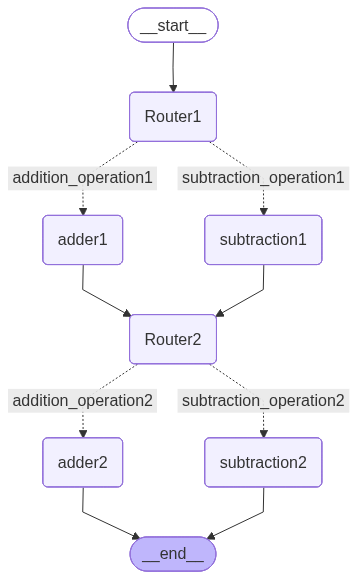

In [9]:
from IPython.display import Image,display
display(Image(app.get_graph().draw_mermaid_png()))

In [10]:
initial_state=AgentState(number1=10,operation1="+",number2=10,number3=8,operation2="-",number4=4,final1=0,final2=0)
print(app.invoke(initial_state))

{'number1': 10, 'operation1': '+', 'number2': 10, 'final1': 20, 'number3': 8, 'operation2': '-', 'number4': 4, 'final2': 4}
